In [38]:
import hashlib
import json
import math
import os
import re
from itertools import combinations
from collections import Counter
import pandas
import pandas as pd
import torch
import tqdm
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
meta_df = pd.read_csv('data/meta/bing.csv', sep = ',')
meta_df

,image_id,klass,source,source_url,orig_path,orig_filename,width,height,added_at
0,5c157ab6250368ab3e9947b4a07614644f8e8794,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000026.jpg,1000,667,2025-10-04T18:00:21Z
1,f5919fa1605f852dcc8b4d80ac4dc1376c57a8e7,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000032.jpg,800,533,2025-10-04T18:00:21Z
2,8960123252d5bbd4c251a3d452e955553701228a,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000033.jpg,1000,667,2025-10-04T18:00:21Z
3,a50a5b43662152fcd023af3e1600abe6bdf3c17d,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000019.jpg,1300,1040,2025-10-04T18:00:21Z
4,0b56d01b6d13c3e2361719466d985296721e4aa8,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000031.jpg,1000,667,2025-10-04T18:00:21Z
...,...,...,...,...,...,...,...,...,...
1476,d9c10b61fa1b3f33951504c74f2e41d2b83ac5a0,porter,bing,NaN,/Users/ivantyshchenko/Projects/Python/Neural-B...,000032.jpg,626,626,2025-10-05T09:14:14Z
1477,66afb5380aa105bbbf0364be4cc306e86348dfb4,sour,bing,NaN,/Users/ivantyshchenko/Projects/Python/Neural-B...,000007.jpg,943,694,2025-10-05T09:17:13Z
1478,9ca409555bd256af367ae57eb7af18174ea5ad2f,sour,bing,NaN,/Users/ivantyshchenko/Projects/Python/Neural-B...,000028.jpg,720,1080,2025-10-05T09:17:13Z
1479,e7c225e7e0ac6706d234b4e77ec42ab9e0ddb53d,sour,bing,NaN,/Users/ivantyshchenko/Projects/Python/Neural-B...,000091.jpg,1470,980,2025-10-05T09:18:42Z


# вах вах
## Preprocessing
### pHash and Hamming distance

In [9]:
import imagehash

def compute_phash(path):
    if isinstance(path, float) and math.isnan(path):
        return None
    if not path or not os.path.exists(path):
        return None
    try:
        with Image.open(path) as img:
            return str(imagehash.phash(img))
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None

meta_df['phash'] = meta_df['orig_path'].apply(compute_phash)


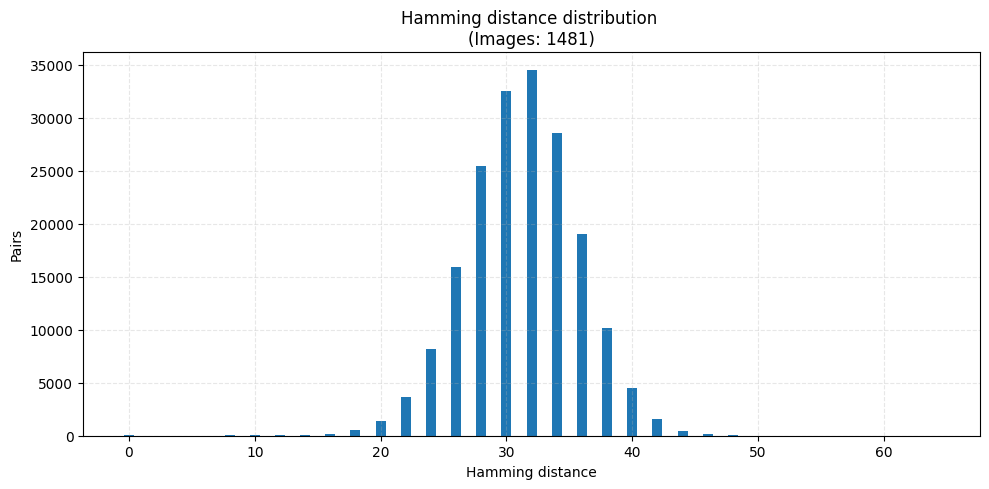

In [10]:
def hamming_dist_hex(h1_hex, h2_hex):
    return (int(h1_hex, 16) ^ int(h2_hex, 16)).bit_count()

dist_counter = Counter()
for klass, group in meta_df.groupby('klass'):
    ph_list =  ph_list = group["phash"].astype(str).tolist()
    if len(ph_list) < 2:
        continue
    for i, j in combinations(range(len(ph_list)), 2):
        d = hamming_dist_hex(ph_list[i], ph_list[j])
        dist_counter[d] += 1

max_d = 64
xs = list(range(0, max_d + 1))
ys = [dist_counter.get(d, 0) for d in xs]

plt.figure(figsize=(10, 5))
plt.bar(xs, ys)
plt.title(f"Hamming distance distribution \n(Images: {len(meta_df)})")
plt.xlabel("Hamming distance")
plt.ylabel("Pairs")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

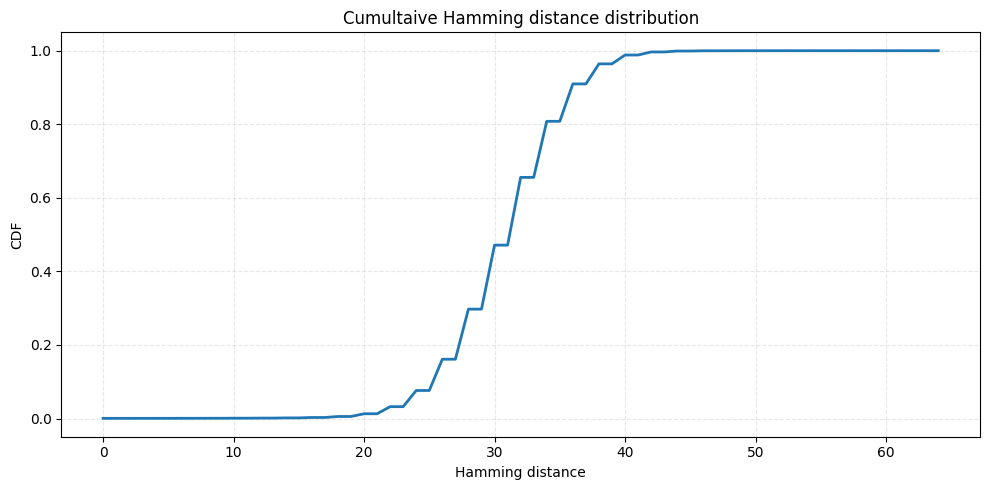

In [11]:
total_pairs = sum(ys)
cdf = np.cumsum(ys) / total_pairs

plt.figure(figsize=(10, 5))
plt.plot(xs, cdf, linewidth=2)
plt.title("Cumultaive Hamming distance distribution")
plt.xlabel("Hamming distance")
plt.ylabel("CDF")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion
The Hamming distance distribution forms a near-perfect bell curve centered around 30–32, which is typical for 64-bit perceptual hashes of visually distinct images.
The CDF confirms that almost all image pairs have distances above 20, indicating that the dataset contains few or no duplicates. Overall, the collection appears clean, diverse, and well-balanced in terms of visual similarity.

In [39]:
from transformers import pipeline

# --- config ---
input_col = "orig_path"
output_dir = Path("data/smart_cropped") #Worked badly with string
target_size = 512
score_threshold = 0.7
padding = 0.08
preferred_labels = {"bottle", "cup", "wine glass", "can"}
output_dir.mkdir(parents=True, exist_ok=True)


detector = pipeline("object-detection", model="facebook/detr-resnet-50")

def expand_box(box, pad, w, h):
    x1, y1, x2, y2 = box
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(w, x2 + pad)
    y2 = min(h, y2 + pad)
    return int(x1), int(y1), int(x2), int(y2)

def choose_best_box(preds, w, h):
    if not preds:
        return None
    norm = []
    for p in preds:
        box = p["box"]
        xmin, ymin = float(box["xmin"]), float(box["ymin"])
        xmax, ymax = float(box["xmax"]), float(box["ymax"])
        norm.append({
            "label": p["label"],
            "score": float(p["score"]),
            "box_xyxy": (xmin, ymin, xmax, ymax),
            "area": (xmax - xmin) * (ymax - ymin),
        })
    norm = [p for p in norm if p["score"] >= score_threshold]
    if not norm:
        return None
    preferred = [p for p in norm if p["label"] in preferred_labels]
    cand = preferred if preferred else norm
    best = max(cand, key=lambda q: (q["score"], q["area"]))
    return best["box_xyxy"], best["label"], best["score"]

def content_aware_crop(path: str | Path):
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            w, h = img.size
            preds = detector(img)

            choice = choose_best_box(preds, w, h)
            if choice is None:
                # fallback center crop
                side = min(w, h)
                cx, cy = w // 2, h // 2
                x1 = int(cx - side / 2)
                y1 = int(cy - side / 2)
                x2 = x1 + side
                y2 = y1 + side
                crop = img.crop((x1, y1, x2, y2))
                if target_size:
                    crop = crop.resize((target_size, target_size), Image.Resampling.LANCZOS)
                return crop, {
                    "method": "center_square_fallback",
                    "label": None,
                    "score": None,
                    "box": [x1, y1, x2, y2],
                }

            (x1, y1, x2, y2), label, score = choice
            pad_px = padding * min(w, h)
            x1, y1, x2, y2 = expand_box((x1, y1, x2, y2), pad_px, w, h)
            crop = img.crop((x1, y1, x2, y2))
            if target_size:
                crop = crop.resize((target_size, target_size), Image.Resampling.LANCZOS)
            return crop, {
                "method": "detr_object_crop",
                "label": label,
                "score": float(score),
                "box": [int(x1), int(y1), int(x2), int(y2)],
            }
    except Exception as e:
        return None, {"method": "error", "error": str(e)}

def _common_root(paths):
    paths = [p for p in paths if isinstance(p, str) and os.path.exists(p)]
    if not paths:
        return None
    try:
        return Path(os.path.commonpath(paths))
    except Exception:
        return None

def _sanitize(stem: str) -> str:
    s = re.sub(r"[^A-Za-z0-9._-]+", "_", stem).strip("._-")
    return s or "img"

common_root = _common_root(meta_df[input_col].dropna().tolist())

def make_out_path(row, output_base: Path = output_dir, common_root: Path | None = common_root) -> Path:
    in_path = Path(row[input_col])
    ext = ".jpg"
    # 1) image_id
    if "image_id" in row and pd.notna(row["image_id"]):
        stem = _sanitize(str(row["image_id"]))
        return output_base / f"{stem}{ext}"
    # 2) дзеркалення структури
    if common_root is not None:
        try:
            rel = in_path.relative_to(common_root)  # e.g., klass/sub/img1.jpg
            return (output_base / rel).with_suffix(ext)
        except Exception:
            pass
    # 3) fallback + хеш
    h = hashlib.sha1(str(in_path).encode("utf-8")).hexdigest()[:10]
    stem = _sanitize(in_path.stem)
    return output_base / f"{stem}_{h}{ext}"

def ensure_unique(path: Path) -> Path:
    if not path.exists():
        return path
    i = 1
    while True:
        candidate = path.with_name(f"{path.stem}-{i}{path.suffix}")
        if not candidate.exists():
            return candidate
        i += 1

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


In [32]:
meta_out = []
for i, row in meta_df.iterrows():
    in_path = row.get(input_col)
    if not isinstance(in_path, str) or not os.path.exists(in_path):
        meta_out.append({**row.to_dict(), "crop_method": "missing", "crop_info": None, "cropped_path": None})
        continue

    cropped, info = content_aware_crop(in_path)
    if cropped is None:
        meta_out.append({**row.to_dict(), "crop_method": info.get("method"), "crop_info": json.dumps(info), "cropped_path": None})
        continue

    out_path = make_out_path(row)
    out_path = ensure_unique(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cropped.save(out_path, quality=95)

    meta_out.append({
        **row.to_dict(),
        "cropped_path": str(out_path),
        "crop_method": info["method"],
        "crop_info": json.dumps(info),
    })

cropped_df = pd.DataFrame(meta_out)
cropped_df.to_csv("data/meta/cropped_meta.csv", index=False)

In [37]:
import cv2
import albumentations as A
input_col = "cropped_path"       # або "orig_path", якщо ще не кропив
input_dir = Path("data/smart_cropped")
output_dir = Path("data/augmented")
meta_dir = Path("data/meta")
meta_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)
n_aug = 4

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.0, 0.05),
        rotate=(-15, 15),
        shear=0,
        p=0.7
    ),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.3),
    A.GaussNoise(p=0.2),
    A.MotionBlur(p=0.2),
])

augmented_rows = []

for i, row in cropped_df.iterrows():
    img_path = row[input_col]
    if not isinstance(img_path, str) or not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for k in range(n_aug):
        aug = transform(image=img)["image"]

        base_name = Path(img_path).stem
        h = hashlib.sha1(f"{img_path}_{k}".encode("utf-8")).hexdigest()[:8]
        out_name = f"{base_name}_aug{k+1}_{h}.jpg"
        out_path = output_dir / out_name

        cv2.imwrite(str(out_path), cv2.cvtColor(aug, cv2.COLOR_RGB2BGR))

        new_row = row.to_dict()
        new_row["aug_id"] = f"{row.get('image_id', base_name)}_aug{k+1}"
        new_row["aug_source"] = img_path
        new_row["aug_path"] = str(out_path)
        new_row["aug_params"] = json.dumps({
            "transform_profile": "beer_bottle_default_v1",
            "version": "1.0",
            "index": k + 1
        })
        augmented_rows.append(new_row)

aug_df = pd.DataFrame(augmented_rows)
out_meta_path = meta_dir / "meta_augmented.csv"
aug_df.to_csv(out_meta_path, index=False)
